# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 14 de Abril de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie y si estan enfermas o no.

## 1. Importe de librerias

Se cargan las librerías necesarias para manipulación de datos, procesamiento de imágenes y modelado con redes neuronales. Algunas destacadas:

* Pandas y NumPy: Para manejo de datos.
* Matplotlib y Seaborn: Para visualización.
* OpenCV (cv2) y PIL (Image): Para procesamiento de imágenes.
* TensorFlow y Keras: Para construir y entrenar modelos de deep learning.

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [5]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-04-14 19:18:54.701868


## 2. Importe de Datos
* Se importa un archivo CSV (Data_Final.csv) con el listado de imágenes y etiquetas.
* Se eliminan registros de la clase "Orange".
* Se divide el dataset en 80% entrenamiento - 20% prueba, asegurando balance entre clases con stratify.

In [8]:
data=pd.read_csv('Metadatos_Finales.csv', sep=";")
data.head()

,Dataset,Carpeta,Nombre del archivo,Planta,Condición,Saludable,Planta_Estado
0,Cassava Leaf Disease Classification,Cassava,1000015157.jpg,Yuca,Cassava Bacterial Blight (CBB),No,Yuca_sick
1,Cassava Leaf Disease Classification,Cassava,1000201771.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick
2,Cassava Leaf Disease Classification,Cassava,100042118.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick
3,Cassava Leaf Disease Classification,Cassava,1000723321.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick
4,Cassava Leaf Disease Classification,Cassava,1000812911.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick


In [10]:
#Quitar las especies que no tenemos en la bases de datos final 
data = data[data["Planta"] != "Orange"]
data = data[data["Planta"] != "Grape"]
data = data[data["Planta"] != "Pepper_bell"]
data = data[data["Planta"] != "Peach"]

# Cambiar el nombre de la columna
data = data.rename(columns={'Nombre del archivo': 'image_id'})
data = data.rename(columns={'Nombre del archivo': 'image_id'})

#Generar la columna Planta+Estado+Enfermedad
data["Planta_Condición_Enfermedad"] = data["Planta_Estado"] + "_" + data["Condición"]
data.head()

,Dataset,Carpeta,image_id,Planta,Condición,Saludable,Planta_Estado,Planta_Condición_Enfermedad
0,Cassava Leaf Disease Classification,Cassava,1000015157.jpg,Yuca,Cassava Bacterial Blight (CBB),No,Yuca_sick,Yuca_sick_Cassava Bacterial Blight (CBB)
1,Cassava Leaf Disease Classification,Cassava,1000201771.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick,Yuca_sick_Cassava Mosaic Disease (CMD)
2,Cassava Leaf Disease Classification,Cassava,100042118.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick,Yuca_sick_Cassava Brown Streak Disease (CBSD)
3,Cassava Leaf Disease Classification,Cassava,1000723321.jpg,Yuca,Cassava Brown Streak Disease (CBSD),No,Yuca_sick,Yuca_sick_Cassava Brown Streak Disease (CBSD)
4,Cassava Leaf Disease Classification,Cassava,1000812911.jpg,Yuca,Cassava Mosaic Disease (CMD),No,Yuca_sick,Yuca_sick_Cassava Mosaic Disease (CMD)


### 2.1. Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [13]:
train, test= train_test_split(data, test_size=0.2, random_state=42,shuffle=True, stratify=data['Planta_Condición_Enfermedad'])
train.shape, test.shape

((42354, 8), (10589, 8))

In [15]:
num_categorias = train['Planta_Condición_Enfermedad'].nunique()
print(num_categorias)

37


### 2.2. Conteo de imágenes por en el conjunto train por categoría

In [18]:
train.Planta_Condición_Enfermedad.value_counts()

Planta_Condición_Enfermedad
Yuca_sick_Cassava Mosaic Disease (CMD)                   10526
Tomato_sick_Tomato_Yellow_Leaf_Curl_Virus                 4285
Yuca_healthy_healthy                                      2061
Yuca_sick_Cassava Green Mottle (CGM)                      1909
Yuca_sick_Cassava Brown Streak Disease (CBSD)             1751
Tomato_sick_Bacterial_spot                                1701
Tomato_sick_Late_blight                                   1527
Tomato_sick_Septoria_leaf_spot                            1417
Tomato_sick_Spider_mites Two-spotted_spider_mite          1341
Apple_healthy_healthy                                     1316
Tomato_healthy_healthy                                    1273
Tomato_sick_Target_Spot                                   1123
Corn_(maize)_sick_Common_rust_                             954
Corn_(maize)_healthy_healthy                               930
Strawberry_sick_Leaf_scorch                                887
Yuca_sick_Cassava Bacterial

### 2.3. Conteo de imágenes por en el conjunto test por categoría

In [21]:
test.Planta_Condición_Enfermedad.value_counts()

Planta_Condición_Enfermedad
Yuca_sick_Cassava Mosaic Disease (CMD)                   2632
Tomato_sick_Tomato_Yellow_Leaf_Curl_Virus                1072
Yuca_healthy_healthy                                      516
Yuca_sick_Cassava Green Mottle (CGM)                      477
Yuca_sick_Cassava Brown Streak Disease (CBSD)             438
Tomato_sick_Bacterial_spot                                426
Tomato_sick_Late_blight                                   382
Tomato_sick_Septoria_leaf_spot                            354
Tomato_sick_Spider_mites Two-spotted_spider_mite          335
Apple_healthy_healthy                                     329
Tomato_healthy_healthy                                    318
Tomato_sick_Target_Spot                                   281
Corn_(maize)_sick_Common_rust_                            238
Corn_(maize)_healthy_healthy                              232
Strawberry_sick_Leaf_scorch                               222
Yuca_sick_Cassava Bacterial Blight (CBB)  

## 4. Preparación del Modelo

* Se implementará data augmentation para mejorar la generalización.
* Se evaluará el modelo con métricas como precisión y recall.

In [24]:
# Hiperparámetros principales
BATCH_SIZE = 8
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 1
TARGET_SIZE = 150

In [26]:
train.Planta_Condición_Enfermedad = train.Planta_Condición_Enfermedad.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 33880 validated image filenames belonging to 37 classes.
Found 8470 validated image filenames belonging to 37 classes.


## 5. Construcción del Modelo

### 5.1. Clasificador

**Arquitectura del Modelo CNN**
El modelo es una red neuronal convolucional (**CNN**) diseñada para clasificar imágenes de plantas en distintas categorías. Su arquitectura incluye:

**1. Capas Convolucionales y de MaxPooling**
Cada capa convolucional extrae características de las imágenes, mientras que **MaxPooling** reduce la dimensionalidad, mejorando la eficiencia del modelo.

- **Capa 1:**  
  - `Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3))`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 2:**  
  - `Conv2D(64, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 3:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 4:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

**2. Capa de Aplanamiento**
Después de las capas convolucionales, se usa `Flatten()` para convertir la salida en un vector de una dimensión.

**3. Capas Densas y Regularización**
- Una capa densa con **512 neuronas** y función de activación ReLU.
- Se usa **Dropout (0.5)** para reducir el sobreajuste.
  
**4. Capa de Salida**
- `Dense(14, activation='softmax')`  
- La activación **softmax** se usa porque se trata de un problema de clasificación multiclase (14 categorías).

In [30]:
# Arquitectura del modelo CNN
model = models.Sequential()

# Capa 1: Convolucional y MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 2: Convolucional y MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 3: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 4: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Aplanamiento de la capa convolucional
model.add(layers.Flatten())

# Clasificador
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout para evitar el overfitting

# Capa de salida
model.add(layers.Dense(num_categorias, activation='softmax'))  

### 5.2. Compilación del modelo

In [33]:
model.compile(
    loss='categorical_crossentropy',  # Cambiado a 'categorical_crossentropy' para múltiples clases
    optimizer='adam',
    metrics=['accuracy']
)

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,472,997 (13.25 MB)

 Trainable params: 3,472,293 (13.25 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Ejecución del modelo

* Se entrenará el modelo utilizando Adam como optimizador y EarlyStopping para prevenir sobreajuste.
* Se evaluará el desempeño sobre el conjunto de prueba.

In [38]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [51]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2)

4235/4235 - 537s - 127ms/step - accuracy: 0.4731 - loss: 1.8075 - val_accuracy: 0.2711 - val_loss: 4.1151 - learning_rate: 0.0010


### 6.1. Resultados del Modelo

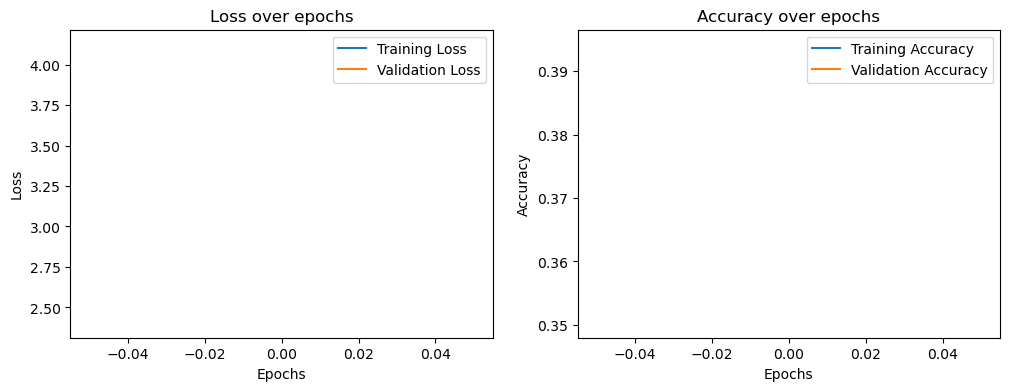

In [41]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [42]:
epochs = [1]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

   Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      1        2.399166         4.129281           0.394333   

   Validation  Accuracy  
0              0.350177  


In [43]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-04-14 19:28:18.867658
Duración: 0:09:24.165790


In [44]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [45]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])

print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 2.3991658687591553
Pérdida final en Validation: 4.1292805671691895
Accuracy final en Train: 0.3943329453468323
Accuracy final en Validation: 0.3501771092414856


## 7. Evaluación del Modelo

In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [48]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-04-14 19:28:18.889639
Duración: 0:09:24.187771


In [49]:
test.Planta = test.Planta.astype('str')

test_generator =  train_datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 8472 validated image filenames belonging to 37 classes.


In [50]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 58s 55ms/step


In [217]:
# -------------------------
# 1.1. Obtener predicciones completas en un json
# -------------------------

# Obtener nombres de archivo
file_names = test_generator.filenames

# Obtener clases del generador
class_indices = test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Crear la lista de resultados
results = []
for i in range(len(file_names)):
    pred_class_name = index_to_class[y_pred[i]]
    
    # Descomposición de la categoría en Planta_Estado y Condición
    if "_" in pred_class_name:
        planta, condicion = pred_class_name.split("_",1)
    else:
        planta, condicion = pred_class_name, None

    # Descomposición de Planta_Estado en planta y estado
    if "_" in condicion:
        estado, enfermedad = condicion.split("_", 1)
    else:
        estado, enfermedad = condicion, None

    result = {
        "archivo": file_names[i],
        #"prediccion": int(y_pred[i]),
        "prediccion_clase": pred_class_name,
        "Planta": planta,
        "Condición": estado,
        "Enfermedad": enfermedad
    }
    results.append(result)

# Guardar a JSON
with open("resultados_test.json", "w") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

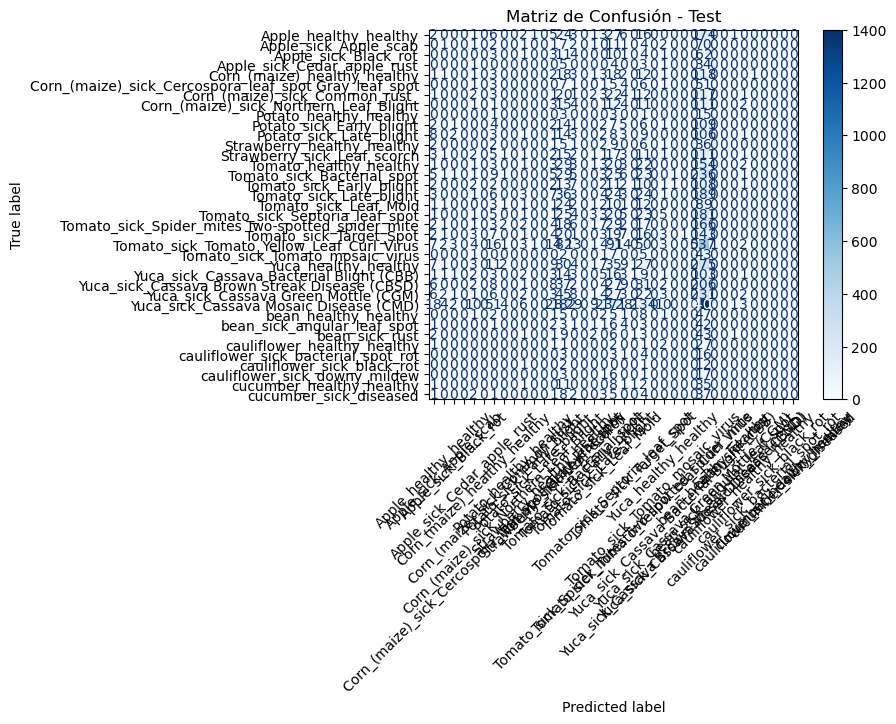

In [64]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()


In [66]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.1792


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


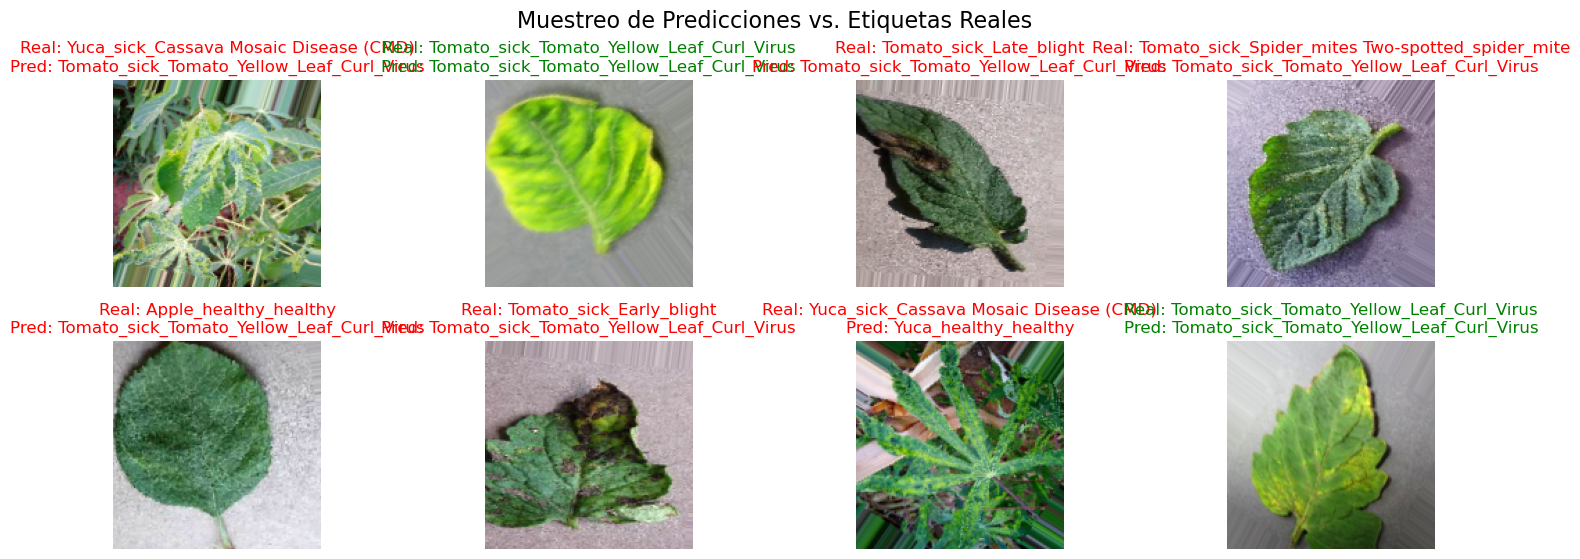

In [68]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

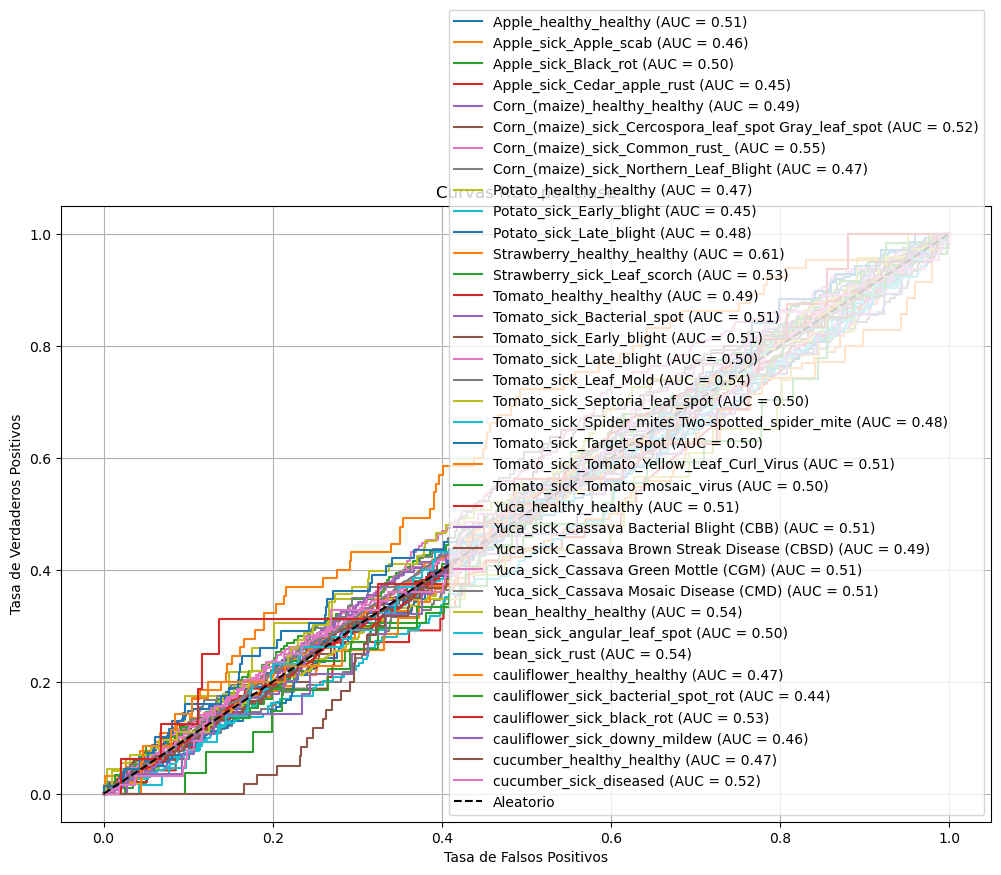

In [70]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [72]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")

AUC Macro promedio: 0.5012
AUC Micro promedio: 0.6394


In [74]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.1792
F1 Score (macro): 0.0183
F1 Score (micro): 0.1792
F1 Score (weighted): 0.1056

Reporte de clasificación por clase:
                                                       precision    recall  f1-score   support

                                Apple_healthy_healthy       0.02      0.01      0.01       272
                                Apple_sick_Apple_scab       0.06      0.01      0.02       104
                                 Apple_sick_Black_rot       0.00      0.00      0.00       100
                          Apple_sick_Cedar_apple_rust       0.00      0.00      0.00        48
                         Corn_(maize)_healthy_healthy       0.02      0.01      0.01       185
Corn_(maize)_sick_Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00        80
                       Corn_(maize)_sick_Common_rust_       0.02      0.02      0.02       190
               Corn_(maize)_sick_Northern_Leaf_Blight       0.00      0.00      0.00       165
            